## 1. Library Initialization and Dependencies

In [2]:
import gymnasium as gym
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from pathlib import Path
import os
import imageio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Hardware Acceleration Verification

In [3]:
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device count: {torch.cuda.device_count()}")
    print(f"Detected GPU: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")
else:
    print("No CUDA GPU detected in current runtime.")
    print("Expected target device: NVIDIA GeForce RTX 3070")

CUDA available: True
GPU device count: 1
Detected GPU: NVIDIA GeForce RTX 3070 Laptop GPU
Current CUDA device index: 0


## 3. Environment Initialization: MountainCar-v0

In [4]:
env = gym.make("MountainCar-v0", render_mode="rgb_array")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)


## 4. Preliminary Baseline: Random Policy Evaluation

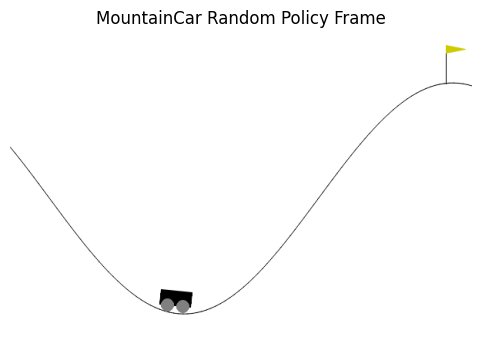

In [5]:
import matplotlib.pyplot as plt

obs, info = env.reset()
frame = None
for _ in range(200):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()
    if terminated or truncated:
        obs, info = env.reset()

plt.figure(figsize=(6, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("MountainCar Random Policy Frame")
plt.show()

## 5. Model Training: Proximal Policy Optimization (PPO)

In [ ]:
from pathlib import Path
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor


class StopOnFirstSuccessCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)

    def _on_step(self) -> bool:
        # 'episode' appears in info when one episode has finished.
        for info in self.locals.get("infos", []):
            if "episode" in info:
                reward = info["episode"]["r"]
                if reward > -160:
                    print(f"High-quality success reached. Episode reward: {reward}. Stopping training.")
                    return False
        return True


log_dir = Path("logs_and_results")
log_dir.mkdir(parents=True, exist_ok=True)

train_env = Monitor(gym.make("MountainCar-v0"))
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    tensorboard_log=str(log_dir / "tensorboard_first_success"),
    device="cuda" if torch.cuda.is_available() else "cpu",
)

callback = StopOnFirstSuccessCallback()
model.learn(
    total_timesteps=100_000_000_000_000,
    callback=callback,
    tb_log_name="ppo_mountain_car_first_success",
)

baseline_final_steps = model.num_timesteps
(log_dir / "baseline_final_steps.txt").write_text(f"{baseline_final_steps}\n", encoding="utf-8")
print(f"Final Step Count (Baseline): {baseline_final_steps}")

model.save(str(log_dir / "mountain_car_first_success"))
train_env.close()
print("Model saved to logs_and_results/mountain_car_first_success.zip")

Using cuda device
Wrapping the env in a DummyVecEnv.
Logging to logs_and_results\tensorboard_first_success\ppo_mountain_car_first_success_2


d:\CodeFiles\RL-Gymnasium-PACSPL602013-Final-Project\final_project_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -200     |
| time/              |          |
|    fps             | 506      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -200         |
| time/                   |              |
|    fps                  | 448          |
|    iterations           | 2            |
|    time_elapsed         | 9            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0093867835 |
|    clip_fraction        | 0.00137      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | 0.00216      |
|    learning_r

## 6. Results Visualization and Video Assessment

In [11]:
import imageio.v2 as imageio
from IPython.display import Video
import numpy as np

model_path = "logs_and_results/mountain_car_first_success.zip"
video_path = "logs_and_results/mountain_car_first_success_demo.mp4"

loaded_model = PPO.load(model_path)
video_env = gym.make("MountainCar-v0", render_mode="rgb_array")

best_frames = []
best_reward = -np.inf

print("Evaluating model to catch the success moment...")
for i in range(5):
    current_frames = []
    total_reward = 0
    obs, info = video_env.reset()
    terminated = False
    truncated = False
    
    while not (terminated or truncated):
        frame = video_env.render()
        current_frames.append(frame)
        action, _ = loaded_model.predict(obs, deterministic=False) 
        obs, reward, terminated, truncated, info = video_env.step(action)
        total_reward += reward
    
    print(f"Attempt {i+1}: Reward = {total_reward}")
    
    if total_reward > best_reward:
        best_reward = total_reward
        best_frames = current_frames

if best_reward > -200:
    print(f"🚀 Found a successful run! Best Reward: {best_reward}")
else:
    print("⚠️ Still struggling. This confirms why we need VLM guidance!")

imageio.mimsave(video_path, best_frames, fps=30)
video_env.close()
Video(video_path, embed=True)

Evaluating model to catch the success moment...
Attempt 1: Reward = -200.0
Attempt 2: Reward = -200.0
Attempt 3: Reward = -200.0
Attempt 4: Reward = -200.0


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Attempt 5: Reward = -200.0
⚠️ Still struggling. This confirms why we need VLM guidance!
